In [3]:
import os, json, pickle, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURE_DIR = Path("/kaggle/input/datasets/yagi19611/amazon-features/amazon_feature")
MODEL_DIR = Path("/kaggle/input/notebooks/yagi19611/notebook-04-gru4rec/models/gru4rec/best_model.pt")
OUTPUT_DIR = Path("/kaggle/working/evaluation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with open(FEATURE_DIR / "feature_config.json") as f:
    CFG = json.load(f)

N_ITEMS = CFG["N_ITEMS"]
TOP_K_LIST = [5, 10, 20]
BATCH_SIZE = 1024

print(f"Device đang dùng: {DEVICE} | Tổng số Items: {N_ITEMS:,}")

Device đang dùng: cuda | Tổng số Items: 667,278


In [4]:
# 1. Định nghĩa Dataset
class SeqDataset(Dataset):
    def __init__(self, inputs_tensor, targets_tensor):
        self.inputs  = inputs_tensor
        self.targets = targets_tensor
    def __len__(self): return len(self.targets)
    def __getitem__(self, idx): return self.inputs[idx], self.targets[idx]

# 2. Định nghĩa kiến trúc GRU4Rec
class GRU4Rec(nn.Module):
    def __init__(self, n_items, embed_dim, hidden_size, n_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.hidden_size = hidden_size
        self.item_emb = nn.Embedding(n_items, embed_dim, padding_idx=pad_idx)
        self.emb_drop = nn.Dropout(dropout)
        self.gru = nn.GRU(embed_dim, hidden_size, n_layers, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.out_drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, n_items, bias=False)
        if embed_dim == hidden_size: self.fc.weight = self.item_emb.weight

    def forward(self, seq):
        lengths = (seq != 0).sum(dim=1).clamp(min=1)
        emb = self.emb_drop(self.item_emb(seq))
        out, _ = self.gru(emb)
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, self.hidden_size)
        last_h = out.gather(1, idx).squeeze(1)
        return self.fc(self.out_drop(self.layer_norm(last_h)))

# 3. Load Test Data
print("Đang nạp tập Test...")
with open(FEATURE_DIR / "gru4rec_test.pkl", "rb") as f:
    test_samples = pickle.load(f)

test_inputs = torch.tensor([s[0] for s in test_samples], dtype=torch.long)
test_targets = torch.tensor([s[1] for s in test_samples], dtype=torch.long)
test_loader = DataLoader(SeqDataset(test_inputs, test_targets), batch_size=BATCH_SIZE, shuffle=False)

# 4. Khởi tạo Model
model = GRU4Rec(
    n_items=N_ITEMS, 
    embed_dim=CFG["embed_dim"], 
    hidden_size=CFG["gru_hidden"],
    n_layers=CFG["gru_layers"]
).to(DEVICE)
print("Load Model & Data hoàn tất!")

Đang nạp tập Test...
Load Model & Data hoàn tất!


In [6]:
# Hàm Evaluate Vector hóa 100% (Xóa bỏ nút thắt cổ chai)
@torch.no_grad()
def evaluate_fast(model, loader, top_k_list, n_neg=100):
    model.eval()
    hits = {k: 0.0 for k in top_k_list}
    ndcgs = {k: 0.0 for k in top_k_list}
    mrr, total = 0.0, 0

    for seq, target in tqdm(loader, desc="Test Eval", leave=True):
        seq, target = seq.to(DEVICE), target.to(DEVICE)
        logits = model(seq)
        B = logits.size(0)

        neg_idx = torch.randint(1, N_ITEMS, (B, n_neg), device=DEVICE)
        pos_score = logits[torch.arange(B, device=DEVICE), target]
        neg_scores = logits.gather(1, neg_idx)

        ranks = (neg_scores > pos_score.unsqueeze(1)).sum(dim=1) + 1
        ranks_float = ranks.float()

        mrr += (1.0 / ranks_float).sum().item()
        for k in top_k_list:
            mask = ranks <= k
            hits[k] += mask.sum().item()
            ndcgs[k] += (1.0 / torch.log2(ranks_float[mask] + 1.0)).sum().item()
        total += B

    return {f"Hit@{k}": round(hits[k]/total, 4) for k in top_k_list} | \
           {f"NDCG@{k}": round(ndcgs[k]/total, 4) for k in top_k_list} | \
           {"MRR": round(mrr/total, 4), "n_samples": total}

# --- THỰC THI ---
best_model_path = Path('/kaggle/input/notebooks/yagi19611/notebook-04-gru4rec/models/gru4rec/best_model.pt')

if best_model_path.exists():
    print(f"==> Bắt đầu nạp trọng số từ: {best_model_path}")
    # Đừng quên weights_only=False để trị cái lỗi bảo mật của PyTorch 2.6
    ckpt = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    print(f"Đã nạp thành công mô hình tốt nhất (Epoch {ckpt['epoch']})")
    
    print("\nBắt đầu chấm điểm trên tập Test...")
    t0 = time.time()
    test_metrics = evaluate_fast(model, test_loader, TOP_K_LIST)
    print(f"\nThời gian chạy: {time.time() - t0:.1f} giây")
    
    print("=== TEST METRICS (100-way ranking) ===")
    for k, v in test_metrics.items():
        print(f"  {k:<12}: {v}")
        
    # Lưu kết quả
    results = {"model": "GRU4Rec", "test_metrics": test_metrics}
    with open(OUTPUT_DIR / "gru4rec_test_results.json", "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nĐã xuất file kết quả tại: {OUTPUT_DIR / 'gru4rec_test_results.json'}")
else:
    print(f"LỖI: Không tìm thấy file model tại {best_model_path}. M kiểm tra lại đường dẫn ở Cell 1 nhé!")

==> Bắt đầu nạp trọng số từ: /kaggle/input/notebooks/yagi19611/notebook-04-gru4rec/models/gru4rec/best_model.pt
Đã nạp thành công mô hình tốt nhất (Epoch 6)

Bắt đầu chấm điểm trên tập Test...


Test Eval:   0%|          | 0/2649 [00:00<?, ?it/s]


Thời gian chạy: 260.1 giây
=== TEST METRICS (100-way ranking) ===
  Hit@5       : 0.4629
  Hit@10      : 0.5816
  Hit@20      : 0.7007
  NDCG@5      : 0.3471
  NDCG@10     : 0.3855
  NDCG@20     : 0.4157
  MRR         : 0.3398
  n_samples   : 2712338

Đã xuất file kết quả tại: /kaggle/working/evaluation/gru4rec_test_results.json


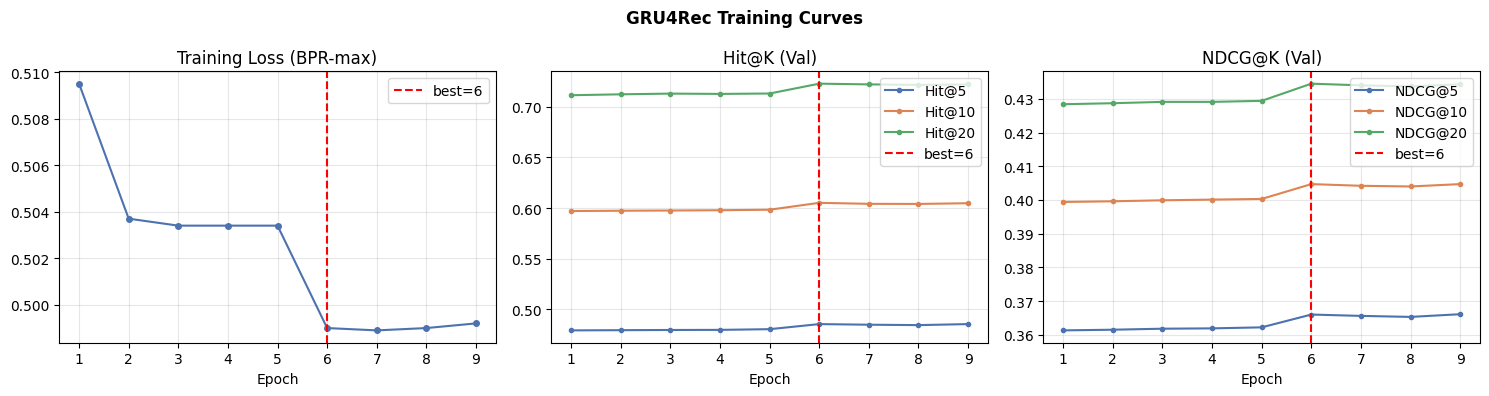

Đã lưu biểu đồ thành công tại → /kaggle/working/evaluation/gru4rec_training.png


In [8]:
log_path = Path('/kaggle/input/notebooks/yagi19611/notebook-04-gru4rec/models/gru4rec/training_log.json')

if not log_path.exists():
    print(f"Không tìm thấy file {log_path}. Không có log thì khỏi vẽ nhé!")
else:
    with open(log_path, "r") as f:
        log_df = pd.DataFrame(json.load(f))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Vẽ Loss
    axes[0].plot(log_df["epoch"], log_df["loss"], marker="o", ms=4, color="#4C72B0")
    axes[0].set_title("Training Loss (BPR-max)"); axes[0].set_xlabel("Epoch")

    # 2. Vẽ Hit@K
    for k, c in zip(TOP_K_LIST, ["#4C72B0","#DD8452","#55A868"]):
        if f"Hit@{k}" in log_df.columns:
            axes[1].plot(log_df["epoch"], log_df[f"Hit@{k}"], marker="o", ms=3, label=f"Hit@{k}", color=c)
    axes[1].set_title("Hit@K (Val)"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    # 3. Vẽ NDCG@K
    for k, c in zip(TOP_K_LIST, ["#4C72B0","#DD8452","#55A868"]):
        if f"NDCG@{k}" in log_df.columns:
            axes[2].plot(log_df["epoch"], log_df[f"NDCG@{k}"], marker="o", ms=3, label=f"NDCG@{k}", color=c)
    axes[2].set_title("NDCG@K (Val)"); axes[2].set_xlabel("Epoch"); axes[2].legend()

    # Tìm lại Best Epoch để kẻ vạch đỏ cho ngầu
    try:
        best_ep = torch.load(MODEL_DIR / "best_model.pt", map_location="cpu", weights_only=False)["epoch"]
    except:
        best_ep = log_df["NDCG@10"].idxmax() + 1 

    for ax in axes:
        ax.axvline(best_ep, ls="--", color="red", lw=1.5, label=f"best={best_ep}")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle("GRU4Rec Training Curves", fontweight="bold")
    plt.tight_layout()

    # Lưu ảnh ra ổ
    fig_path = OUTPUT_DIR / "gru4rec_training.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Đã lưu biểu đồ thành công tại → {fig_path}")